# Main notebook — EfficientNet b0 training
Three-class Medical-Oriented ROI + 2.5D Slice Classification

## 1. Basic imports

In [1]:
# BASIC IMPORTS NEEDED BEFORE LOADING SUPPORT NOTEBOOK
import os
from pathlib import Path

import torch
import pandas as pd


## 2. Configuration

In [2]:
# ----------------------------
# CONFIG
# ----------------------------
ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = ROOT / "BC-data"
PROJECT_ROOT = ROOT / "Classification-baseline"
DATA_CSV = DATA_ROOT / "data-rsna2024" / "data_merged.csv"
os.chdir(ROOT)

# Output folder for trained models and results.
MODEL_ROOT_DIR = Path("models")
BASE_RUN_NAME = "models_classification_EfficientNet_b_96_zoom"

IMAGE_SIZE = 224
BATCH_SIZE = 32

# ROI cropping controls.
# The model architecture stays unchanged: the crop is resized to IMAGE_SIZE.
ROI_CROP_ENABLED = True
ROI_CROP_SIZE = 96        # square crop size in original DICOM pixels before resizing to IMAGE_SIZE
ROI_FALLBACK_TO_FULL_IMAGE = True
X_COLUMN = None            # inferred automatically after loading DATA_CSV
Y_COLUMN = None            # inferred automatically after loading DATA_CSV

# 2.5D slice-context controls.
# If enabled, the 3 input channels are [previous slice, current slice, next slice].
# If disabled, the input is the current grayscale image repeated into 3 channels.
USE_DATA_AUGMENTATION = True
USE_2_5D_INPUT = True
SLICE_CONTEXT_OFFSETS = (-1, 0, 1)
SERIES_GROUP_COLUMNS = None   # inferred automatically, usually ["study_id", "series_id"]
SLICE_ORDER_COLUMN = None     # inferred automatically, usually "instance_number"


# DataLoader performance settings.
NUM_WORKERS = 16
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

# Model-head regularization.
HIDDEN_DIM = 512
DROPOUT = 0.15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 3. Label definitions

In [3]:
# LABEL DEFINITIONS

SEVERITY_MAP = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2,
}

TARGET_NAMES = ["Normal/Mild", "Moderate", "Severe"]
N_CLASSES = len(TARGET_NAMES)

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SIDE_TO_ID = {
    "center": 0,
    "left": 1,
    "right": 2,
}

SERIES_TO_ID = {
    "Sagittal T2/STIR": 0,
    "Sagittal T1": 1,
    "Axial T2": 2,
}

LEVEL_TO_ID = {level: idx for idx, level in enumerate(LEVELS)}


## 4. Define the three classifiers

In [4]:
# CONDITION-SPECIFIC CLASSIFIERS

MODEL_CONFIGS = {
    "spinal_canal_stenosis": {
        "base_condition": "Spinal Canal Stenosis",
        "series_description": "Sagittal T2/STIR",
    },
    "neural_foraminal_narrowing": {
        "base_condition": "Neural Foraminal Narrowing",
        "series_description": "Sagittal T1",
    },
    "subarticular_stenosis": {
        "base_condition": "Subarticular Stenosis",
        "series_description": "Axial T2",
    },
}


## 5. Model selection

In [5]:
# ============================================================
# MODEL SELECTION
# ============================================================
# ResNet: "resnet18", "resnet34", "resnet50"
# DenseNet: "densenet121", "densenet169", "densenet201"
# EfficientNet: "efficientnet_b0", "efficientnet_b1", "efficientnet_b2", "efficientnet_b3", "efficientnet_v2_s"
# Swin Transformers: "swin_t", "swin_s", "swin_b"
# ConvNeXt: "convnext_tiny", "convnext_small", "convnext_base"


SELECTED_BACKBONES = [
    #"resnet50"
    #"densenet121"
    "efficientnet_b0"
    #"convnext_base"
    #"swin_s"
]

# Backward-compatible variable used by helper functions. It is overwritten
# inside the training/testing loops for each selected backbone.
SELECTED_BACKBONE = SELECTED_BACKBONES[0]
PRETRAINED = True

# Use this to train only a subset of clinical classifiers while debugging, for example:
# MODELS_TO_TRAIN = ["spinal_canal_stenosis"]
MODELS_TO_TRAIN = list(MODEL_CONFIGS.keys())

# Shared output folder for normalization/statistics from this multi-backbone run.
OUTPUT_ROOT_DIR = MODEL_ROOT_DIR / f"{BASE_RUN_NAME}_selected_backbones"
OUTPUT_ROOT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = OUTPUT_ROOT_DIR
RUN_NAME = OUTPUT_ROOT_DIR.name


print("Using device:", DEVICE)
print("Project root:", PROJECT_ROOT)
print("Data CSV:", DATA_CSV)
print("Shared output dir:", OUTPUT_ROOT_DIR)
print("Selected backbones:", SELECTED_BACKBONES)
print("Pretrained:", PRETRAINED)
print("Models to train:", MODELS_TO_TRAIN)
print("NUM_WORKERS:", NUM_WORKERS)
print("ROI crop enabled:", ROI_CROP_ENABLED)
print("2.5D input enabled:", USE_2_5D_INPUT)


Using device: cuda
Project root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline
Data CSV: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024/data_merged.csv
Shared output dir: models/models_classification_EfficientNet_b_96_zoom_selected_backbones
Selected backbones: ['efficientnet_b0']
Pretrained: True
Models to train: ['spinal_canal_stenosis', 'neural_foraminal_narrowing', 'subarticular_stenosis']
NUM_WORKERS: 16
ROI crop enabled: True
2.5D input enabled: True


In [6]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================
# This cell controls loss construction, optimizer/scheduler behavior,
# checkpoint selection, and early stopping.

# ----------------------------
# Epochs and early stopping
# ----------------------------
EPOCHS = 30
MIN_EPOCHS = 8
PATIENCE = 5
MIN_DELTA = 1e-4

# ----------------------------
# Loss configuration
# ----------------------------
#   "weighted_cross_entropy"  -> inverse-frequency class weights + medical multipliers
#   "cross_entropy"           -> unweighted cross entropy
LOSS_NAME = "weighted_cross_entropy"

# Small label smoothing helps reduce overconfident validation loss explosion.
LABEL_SMOOTHING = 0.03

# Class imbalance and medical-priority controls.
# class 0 = Normal/Mild, class 1 = Moderate, class 2 = Severe.
MODERATE_WEIGHT_MULTIPLIER = 1.0
SEVERE_WEIGHT_MULTIPLIER = 1.1

# Keep sampler off when using class-weighted loss.
USE_WEIGHTED_SAMPLER = False

# ----------------------------
# Optimizer configuration
# ----------------------------
OPTIMIZER_NAME = "adamw"

# Slightly lower LR because ROI/2.5D model appears to overfit very fast.
LR = 1e-5

# Keep pretrained backbone updates small.
BACKBONE_LR_MULTIPLIER = 0.1

# Stronger weight decay for regularization.
WEIGHT_DECAY = 1e-3

GRAD_CLIP_NORM = 1.0

# ----------------------------
# Scheduler configuration
# ----------------------------
# For ReduceLROnPlateau, SCHEDULER_MONITOR must be one key from val_metrics,
# e.g. "loss", "log_loss", "macro_f1", "balanced_accuracy".
SCHEDULER_NAME = "reduce_lr_on_plateau"

# I would monitor early-stop score or macro_f1 if your training loop supports it.
SCHEDULER_MONITOR = "macro_f1"

SCHEDULER_CONFIG = {
    "mode": "max",
    "factor": 0.5,
    "patience": 2,
}

# ----------------------------
# Checkpoint and early-stopping scoring
# ----------------------------
# Less recall-only pressure. This still rewards severe recall,
# but severe F1 and general class balance matter equally.
CHECKPOINT_SCORE_WEIGHTS = {
    "severe_recall": 0.25,
    "severe_f1": 0.30,
    "pathological_f1": 0.20,
    "macro_f1": 0.15,
    "balanced_accuracy": 0.10,
}

# Early stopping should track broad validation generalization.
EARLY_STOP_SCORE_WEIGHTS = {
    "macro_f1": 0.40,
    "balanced_accuracy": 0.40,
    "pathological_f1": 0.20,
}


print("Training config")
print("Loss:", LOSS_NAME)
print("Optimizer:", OPTIMIZER_NAME, "| LR:", LR, "| backbone LR multiplier:", BACKBONE_LR_MULTIPLIER)
print("Weight decay:", WEIGHT_DECAY, "| grad clip:", GRAD_CLIP_NORM)
print("Scheduler:", SCHEDULER_NAME, "| monitor:", SCHEDULER_MONITOR, "| config:", SCHEDULER_CONFIG)
print("Epochs:", EPOCHS, "| min epochs:", MIN_EPOCHS, "| patience:", PATIENCE, "| min delta:", MIN_DELTA)
print("Label smoothing:", LABEL_SMOOTHING)
print("Moderate multiplier:", MODERATE_WEIGHT_MULTIPLIER, "| severe multiplier:", SEVERE_WEIGHT_MULTIPLIER)
print("Checkpoint score weights:", CHECKPOINT_SCORE_WEIGHTS)
print("Early-stop score weights:", EARLY_STOP_SCORE_WEIGHTS)

Training config
Loss: weighted_cross_entropy
Optimizer: adamw | LR: 1e-05 | backbone LR multiplier: 0.1
Weight decay: 0.001 | grad clip: 1.0
Scheduler: reduce_lr_on_plateau | monitor: macro_f1 | config: {'mode': 'max', 'factor': 0.5, 'patience': 2}
Epochs: 30 | min epochs: 8 | patience: 5 | min delta: 0.0001
Label smoothing: 0.03
Moderate multiplier: 1.0 | severe multiplier: 1.1
Checkpoint score weights: {'severe_recall': 0.25, 'severe_f1': 0.3, 'pathological_f1': 0.2, 'macro_f1': 0.15, 'balanced_accuracy': 0.1}
Early-stop score weights: {'macro_f1': 0.4, 'balanced_accuracy': 0.4, 'pathological_f1': 0.2}


## 6. Training configuration

All training-policy choices are centralized here so model comparison can be changed without editing the training loop.

In [7]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================
# This cell controls loss construction, optimizer/scheduler behavior,
# checkpoint selection, and early stopping.

# ----------------------------
# Epochs and early stopping
# ----------------------------
EPOCHS = 50
MIN_EPOCHS = 8
PATIENCE = 10
MIN_DELTA = 1e-4

# ----------------------------
# Loss configuration
# ----------------------------
# Options:
#   "weighted_cross_entropy"  -> inverse-frequency class weights + medical multipliers
#   "cross_entropy"           -> unweighted cross entropy
LOSS_NAME = "weighted_cross_entropy"

# Small label smoothing helps reduce overconfident validation loss explosion.
LABEL_SMOOTHING = 0.03

# Class imbalance and medical-priority controls.
# class 0 = Normal/Mild, class 1 = Moderate, class 2 = Severe.
#
# Keep these mild. The base inverse-frequency weights are already strong.
MODERATE_WEIGHT_MULTIPLIER = 1.0
SEVERE_WEIGHT_MULTIPLIER = 1.1

# Keep sampler off when using class-weighted loss.
# Using both often over-corrects imbalance.
USE_WEIGHTED_SAMPLER = False

# ----------------------------
# Optimizer configuration
# ----------------------------
OPTIMIZER_NAME = "adamw"

# Slightly lower LR because ROI/2.5D model appears to overfit very fast.
LR = 1e-5

# Keep pretrained backbone updates small.
BACKBONE_LR_MULTIPLIER = 0.1

# Stronger weight decay for regularization.
WEIGHT_DECAY = 1e-3

GRAD_CLIP_NORM = 1.0

# ----------------------------
# Scheduler configuration
# ----------------------------
# For ReduceLROnPlateau, SCHEDULER_MONITOR must be one key from val_metrics,
# e.g. "loss", "log_loss", "macro_f1", "balanced_accuracy".
SCHEDULER_NAME = "reduce_lr_on_plateau"

# I would monitor early-stop score or macro_f1 if your training loop supports it.
SCHEDULER_MONITOR = "macro_f1"

SCHEDULER_CONFIG = {
    "mode": "max",
    "factor": 0.5,
    "patience": 2,
}

# ----------------------------
# Checkpoint and early-stopping scoring
# ----------------------------
# Less recall-only pressure. This still rewards severe recall,
# but severe F1 and general class balance matter equally.
CHECKPOINT_SCORE_WEIGHTS = {
    "severe_recall": 0.25,
    "severe_f1": 0.30,
    "pathological_f1": 0.20,
    "macro_f1": 0.15,
    "balanced_accuracy": 0.10,
}

# Early stopping should track broad validation generalization.
EARLY_STOP_SCORE_WEIGHTS = {
    "macro_f1": 0.40,
    "balanced_accuracy": 0.40,
    "pathological_f1": 0.20,
}

print("Training config")
print("Loss:", LOSS_NAME)
print("Optimizer:", OPTIMIZER_NAME, "| LR:", LR, "| backbone LR multiplier:", BACKBONE_LR_MULTIPLIER)
print("Weight decay:", WEIGHT_DECAY, "| grad clip:", GRAD_CLIP_NORM)
print("Scheduler:", SCHEDULER_NAME, "| monitor:", SCHEDULER_MONITOR, "| config:", SCHEDULER_CONFIG)
print("Epochs:", EPOCHS, "| min epochs:", MIN_EPOCHS, "| patience:", PATIENCE, "| min delta:", MIN_DELTA)
print("Label smoothing:", LABEL_SMOOTHING)
print("Moderate multiplier:", MODERATE_WEIGHT_MULTIPLIER, "| severe multiplier:", SEVERE_WEIGHT_MULTIPLIER)
print("Checkpoint score weights:", CHECKPOINT_SCORE_WEIGHTS)
print("Early-stop score weights:", EARLY_STOP_SCORE_WEIGHTS)

Training config
Loss: weighted_cross_entropy
Optimizer: adamw | LR: 1e-05 | backbone LR multiplier: 0.1
Weight decay: 0.001 | grad clip: 1.0
Scheduler: reduce_lr_on_plateau | monitor: macro_f1 | config: {'mode': 'max', 'factor': 0.5, 'patience': 2}
Epochs: 50 | min epochs: 8 | patience: 10 | min delta: 0.0001
Label smoothing: 0.03
Moderate multiplier: 1.0 | severe multiplier: 1.1
Checkpoint score weights: {'severe_recall': 0.25, 'severe_f1': 0.3, 'pathological_f1': 0.2, 'macro_f1': 0.15, 'balanced_accuracy': 0.1}
Early-stop score weights: {'macro_f1': 0.4, 'balanced_accuracy': 0.4, 'pathological_f1': 0.2}


## 6. Load support functions

In [8]:
# Load reusable functions/classes from the companion notebook.
# Keep both notebooks in the same folder when running this main notebook.
MODEL_NAMES = [
    "swin_s",
    "resnet34",
    "efficientnet_b0",
    "convnext_base",
]
%run ./Classification-baseline/100_class_support_functions.ipynb

## 7. Reproducibility

In [9]:
set_seed(42)

## 8. Load and prepare dataframe

This section creates `base_condition`, `side`, and `target`, then infers ROI and 2.5D slice-order metadata.

In [10]:
# LOAD AND PREPARE DATAFRAME

data_merged = pd.read_csv(DATA_CSV)

data_merged["side"] = data_merged["condition"].apply(extract_side)
data_merged["base_condition"] = data_merged["condition"].apply(extract_base_condition)
data_merged["target"] = data_merged["severity"].map(SEVERITY_MAP)

# Infer ROI coordinate columns.
if ROI_CROP_ENABLED:
    inferred_x_col, inferred_y_col = infer_coordinate_columns(data_merged)

    if X_COLUMN is None:
        X_COLUMN = inferred_x_col
    if Y_COLUMN is None:
        Y_COLUMN = inferred_y_col

    print("ROI cropping enabled:", ROI_CROP_ENABLED)
    print("ROI x column:", X_COLUMN)
    print("ROI y column:", Y_COLUMN)

    if X_COLUMN is None or Y_COLUMN is None:
        print("WARNING: Coordinate columns were not found. The dataset will fall back to full images.")
    else:
        data_merged[X_COLUMN] = pd.to_numeric(data_merged[X_COLUMN], errors="coerce")
        data_merged[Y_COLUMN] = pd.to_numeric(data_merged[Y_COLUMN], errors="coerce")

        missing_roi = data_merged[[X_COLUMN, Y_COLUMN]].isna().any(axis=1).sum()
        print(f"Rows with missing ROI coordinates: {missing_roi} / {len(data_merged)}")

# Infer 2.5D series grouping and slice ordering.
if USE_2_5D_INPUT:
    if SERIES_GROUP_COLUMNS is None:
        SERIES_GROUP_COLUMNS = infer_series_group_columns(data_merged)

    if SLICE_ORDER_COLUMN is None:
        SLICE_ORDER_COLUMN = infer_slice_order_column(data_merged)

    if SLICE_ORDER_COLUMN is None:
        SLICE_ORDER_COLUMN = "_slice_order_from_path"
        data_merged[SLICE_ORDER_COLUMN] = data_merged["img_path"].apply(parse_slice_order_from_path)

    print("2.5D input enabled:", USE_2_5D_INPUT)
    print("Series group columns:", SERIES_GROUP_COLUMNS)
    print("Slice order column:", SLICE_ORDER_COLUMN)

    if SERIES_GROUP_COLUMNS == ["study_id", "series_description"]:
        print(
            "WARNING: No explicit series_id column was found. "
            "Using study_id + series_description as a fallback for neighbouring slices."
        )


data_merged = data_merged.dropna(subset=[
    "study_id",
    "img_path",
    "target",
    "level",
    "side",
    "series_description",
]).copy()

if USE_2_5D_INPUT:
    data_merged[SLICE_ORDER_COLUMN] = pd.to_numeric(
        data_merged[SLICE_ORDER_COLUMN],
        errors="coerce",
    )

data_merged["target"] = data_merged["target"].astype(int)
print(data_merged["base_condition"].value_counts())
print("==========================")
print(data_merged["series_description"].value_counts())
#display(data_merged.head())


ROI cropping enabled: True
ROI x column: x
ROI y column: y
Rows with missing ROI coordinates: 0 / 48677
2.5D input enabled: True
Series group columns: ['study_id', 'series_id']
Slice order column: instance_number
base_condition
Neural Foraminal Narrowing    19689
Subarticular Stenosis         19215
Spinal Canal Stenosis          9738
Name: count, dtype: int64
series_description
Sagittal T1         19694
Axial T2            19215
Sagittal T2/STIR     9733
Name: count, dtype: int64


## 9. Study-level train/validation/test split

Split is created by `study_id`, which prevents patient/study leakage.

In [11]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

# First split: train vs temporary validation + test
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    gss1.split(
        data_merged,
        groups=data_merged["study_id"],
    )
)

train_df = data_merged.iloc[train_idx].copy()
temp_df = data_merged.iloc[temp_idx].copy()

# Second split: validation vs test from the temporary set
val_relative_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=val_relative_size,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["study_id"],
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Rows:")
print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

print("\nUnique studies:")
print("train:", train_df["study_id"].nunique())
print("val:  ", val_df["study_id"].nunique())
print("test: ", test_df["study_id"].nunique())

Rows:
train: (34033, 18)
val:   (7288, 18)
test:  (7321, 18)

Unique studies:
train: 1381
val:   296
test:  297


## 10. Split distribution checks

In [12]:
# Cell 1: prepare merged dataframe
plot_df = pd.concat(
    [
        train_df[["condition", "base_condition", "severity"]].assign(split="train"),
        val_df[["condition", "base_condition", "severity"]].assign(split="val"),
        test_df[["condition", "base_condition", "severity"]].assign(split="test"),
    ],
    ignore_index=True,
)

plot_df["condition_plot"] = plot_df["base_condition"]

plot_df.loc[
    plot_df["condition"].str.contains("Left Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Left Neural Foraminal Narrowing"

plot_df.loc[
    plot_df["condition"].str.contains("Right Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Right Neural Foraminal Narrowing"

severity_order = ["Normal/Mild", "Moderate", "Severe"]
split_order = ["train", "val", "test"]

plot_df["severity"] = pd.Categorical(plot_df["severity"], categories=severity_order, ordered=True)
plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)

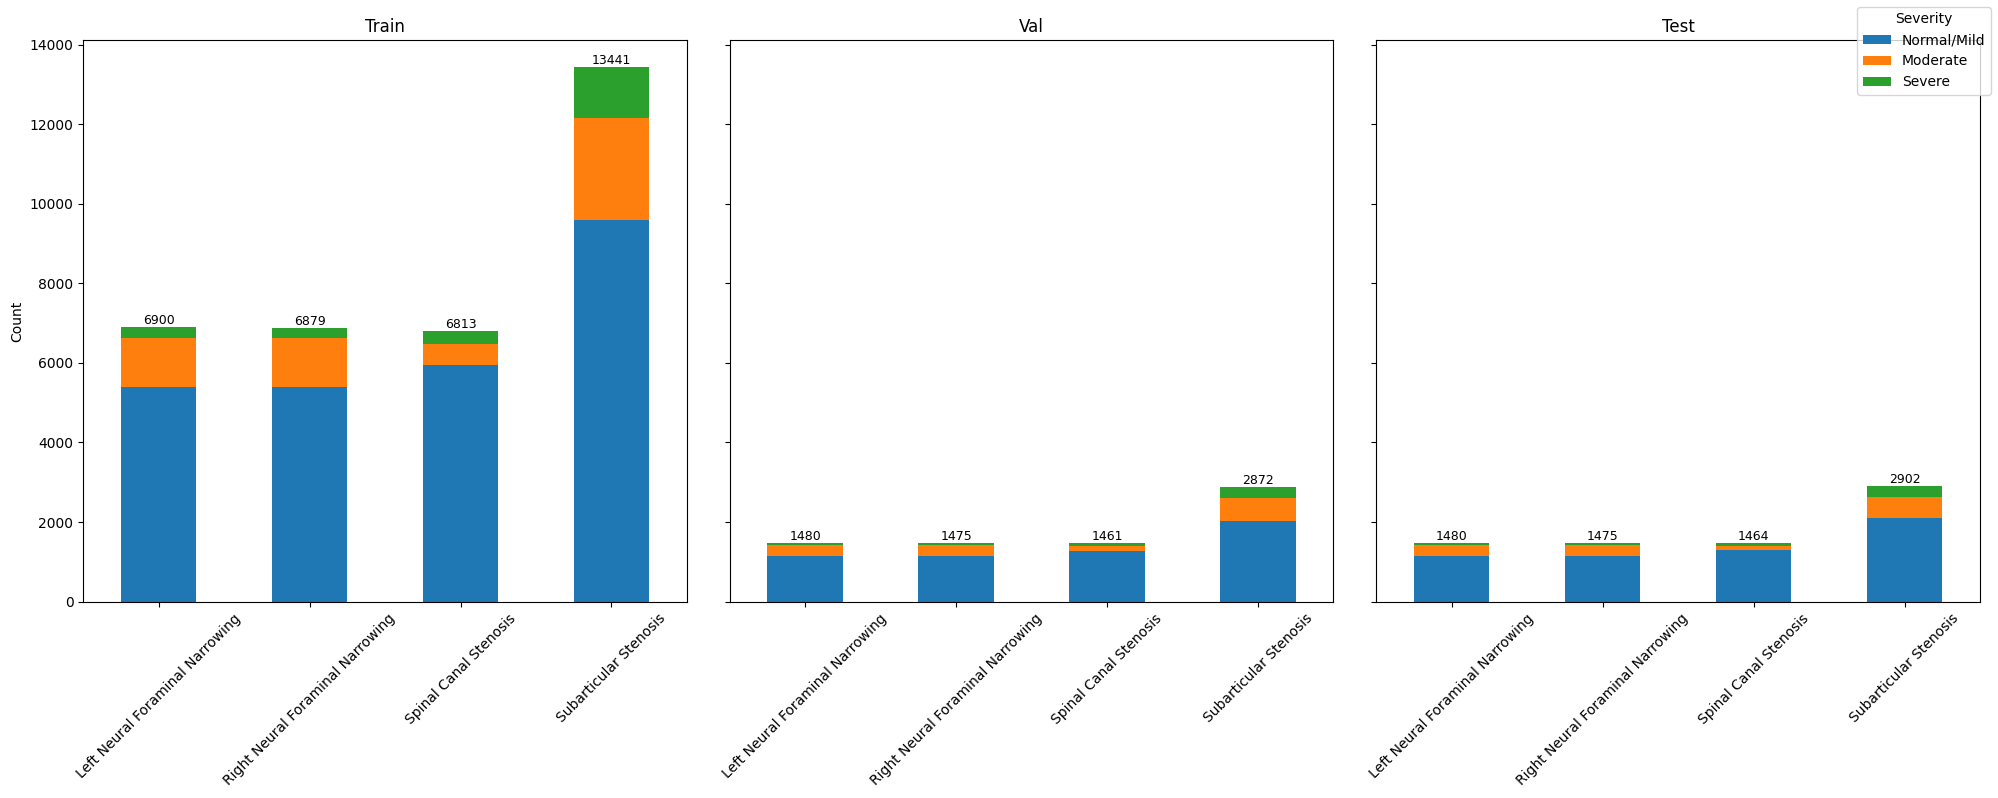

In [13]:
# Cell 2: side-by-side stacked bar charts with total counts

import matplotlib.pyplot as plt

condition_order = sorted(plot_df["condition_plot"].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

for ax, split in zip(axes, split_order):
    split_counts = pd.crosstab(
        plot_df.loc[plot_df["split"] == split, "condition_plot"],
        plot_df.loc[plot_df["split"] == split, "severity"]
    ).reindex(index=condition_order, columns=severity_order, fill_value=0)

    split_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    totals = split_counts.sum(axis=1)

    for i, total in enumerate(totals):
        ax.text(
            i,
            total,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{split.capitalize()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Count")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Severity", loc="upper right")

plt.tight_layout()
plt.show()

## 11. Build condition-specific training tables

In [14]:
model_dfs = {}

for model_name, cfg in MODEL_CONFIGS.items():
    model_dfs[model_name] = {
        "train": make_model_df(train_df, cfg["base_condition"], cfg["series_description"]),
        "val": make_model_df(val_df, cfg["base_condition"], cfg["series_description"]),
        "test": make_model_df(test_df, cfg["base_condition"], cfg["series_description"]),
    }

for model_name, parts in model_dfs.items():
    print("\n", model_name)
    for split_name, split_df in parts.items():
        print(f"{split_name:5s}: {len(split_df):6d} rows | {split_df['study_id'].nunique():4d} studies")
        print(split_df["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))



 spinal_canal_stenosis
train:   6808 rows | 1380 studies
target
Normal/Mild    5953
Moderate        512
Severe          343
Name: count, dtype: int64
val  :   1461 rows |  296 studies
target
Normal/Mild    1281
Moderate        117
Severe           63
Name: count, dtype: int64
test :   1464 rows |  297 studies
target
Normal/Mild    1301
Moderate        101
Severe           62
Name: count, dtype: int64

 neural_foraminal_narrowing
train:  13779 rows | 1380 studies
target
Normal/Mild    10800
Moderate        2462
Severe           517
Name: count, dtype: int64
val  :   2955 rows |  296 studies
target
Normal/Mild    2280
Moderate        538
Severe          137
Name: count, dtype: int64
test :   2955 rows |  296 studies
target
Normal/Mild    2275
Moderate        559
Severe          121
Name: count, dtype: int64

 subarticular_stenosis
train:  13441 rows | 1381 studies
target
Normal/Mild    9601
Moderate       2549
Severe         1291
Name: count, dtype: int64
val  :   2872 rows |  296 studi

## 12. Compute mean and standard deviation from ROI-cropped training data only

Mean/std are computed from the selected classifiers' training rows and from the same input distribution used for training.

In [15]:
# Combine only TRAINING rows from the selected classifiers.
norm_train_df = pd.concat(
    [model_dfs[name]["train"] for name in MODELS_TO_TRAIN],
    axis=0,
    ignore_index=True,
).drop_duplicates(subset=["img_path", "level", "side", "base_condition"])

print("Rows used for mean/std:", len(norm_train_df))

mean, std = compute_mean_std(
    norm_train_df,
    batch_size=32,
    num_workers=NUM_WORKERS,
)

print("Computed mean:", mean)
print("Computed std: ", std)

# Save for reproducibility.
mean_std_suffix = "roi_crop_2p5d" if USE_2_5D_INPUT else "roi_crop_repeated_gray"
pd.DataFrame({"mean": mean, "std": std}).to_csv(
    OUTPUT_DIR / f"computed_train_mean_std_{mean_std_suffix}.csv",
    index=False,
)


Rows used for mean/std: 34028


Computing mean/std:   0%|          | 0/1064 [00:00<?, ?it/s]

Computed mean: [0.30402857065200806, 0.30118006467819214, 0.3036385178565979]
Computed std:  [0.2232816368341446, 0.2231549471616745, 0.22349555790424347]


## 13. Transforms

In [16]:
# TRANSFORMS

train_augmentation = transforms.Compose([
    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0,
    ),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
        )
    ], p=0.50),
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8),
        )
    ], p=0.15),
])

# Deterministic preprocessing used after optional augmentation.
# Do NOT add transforms.Grayscale(num_output_channels=3) here; it would destroy 2.5D slice channels.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])


## 14. Visual sanity check

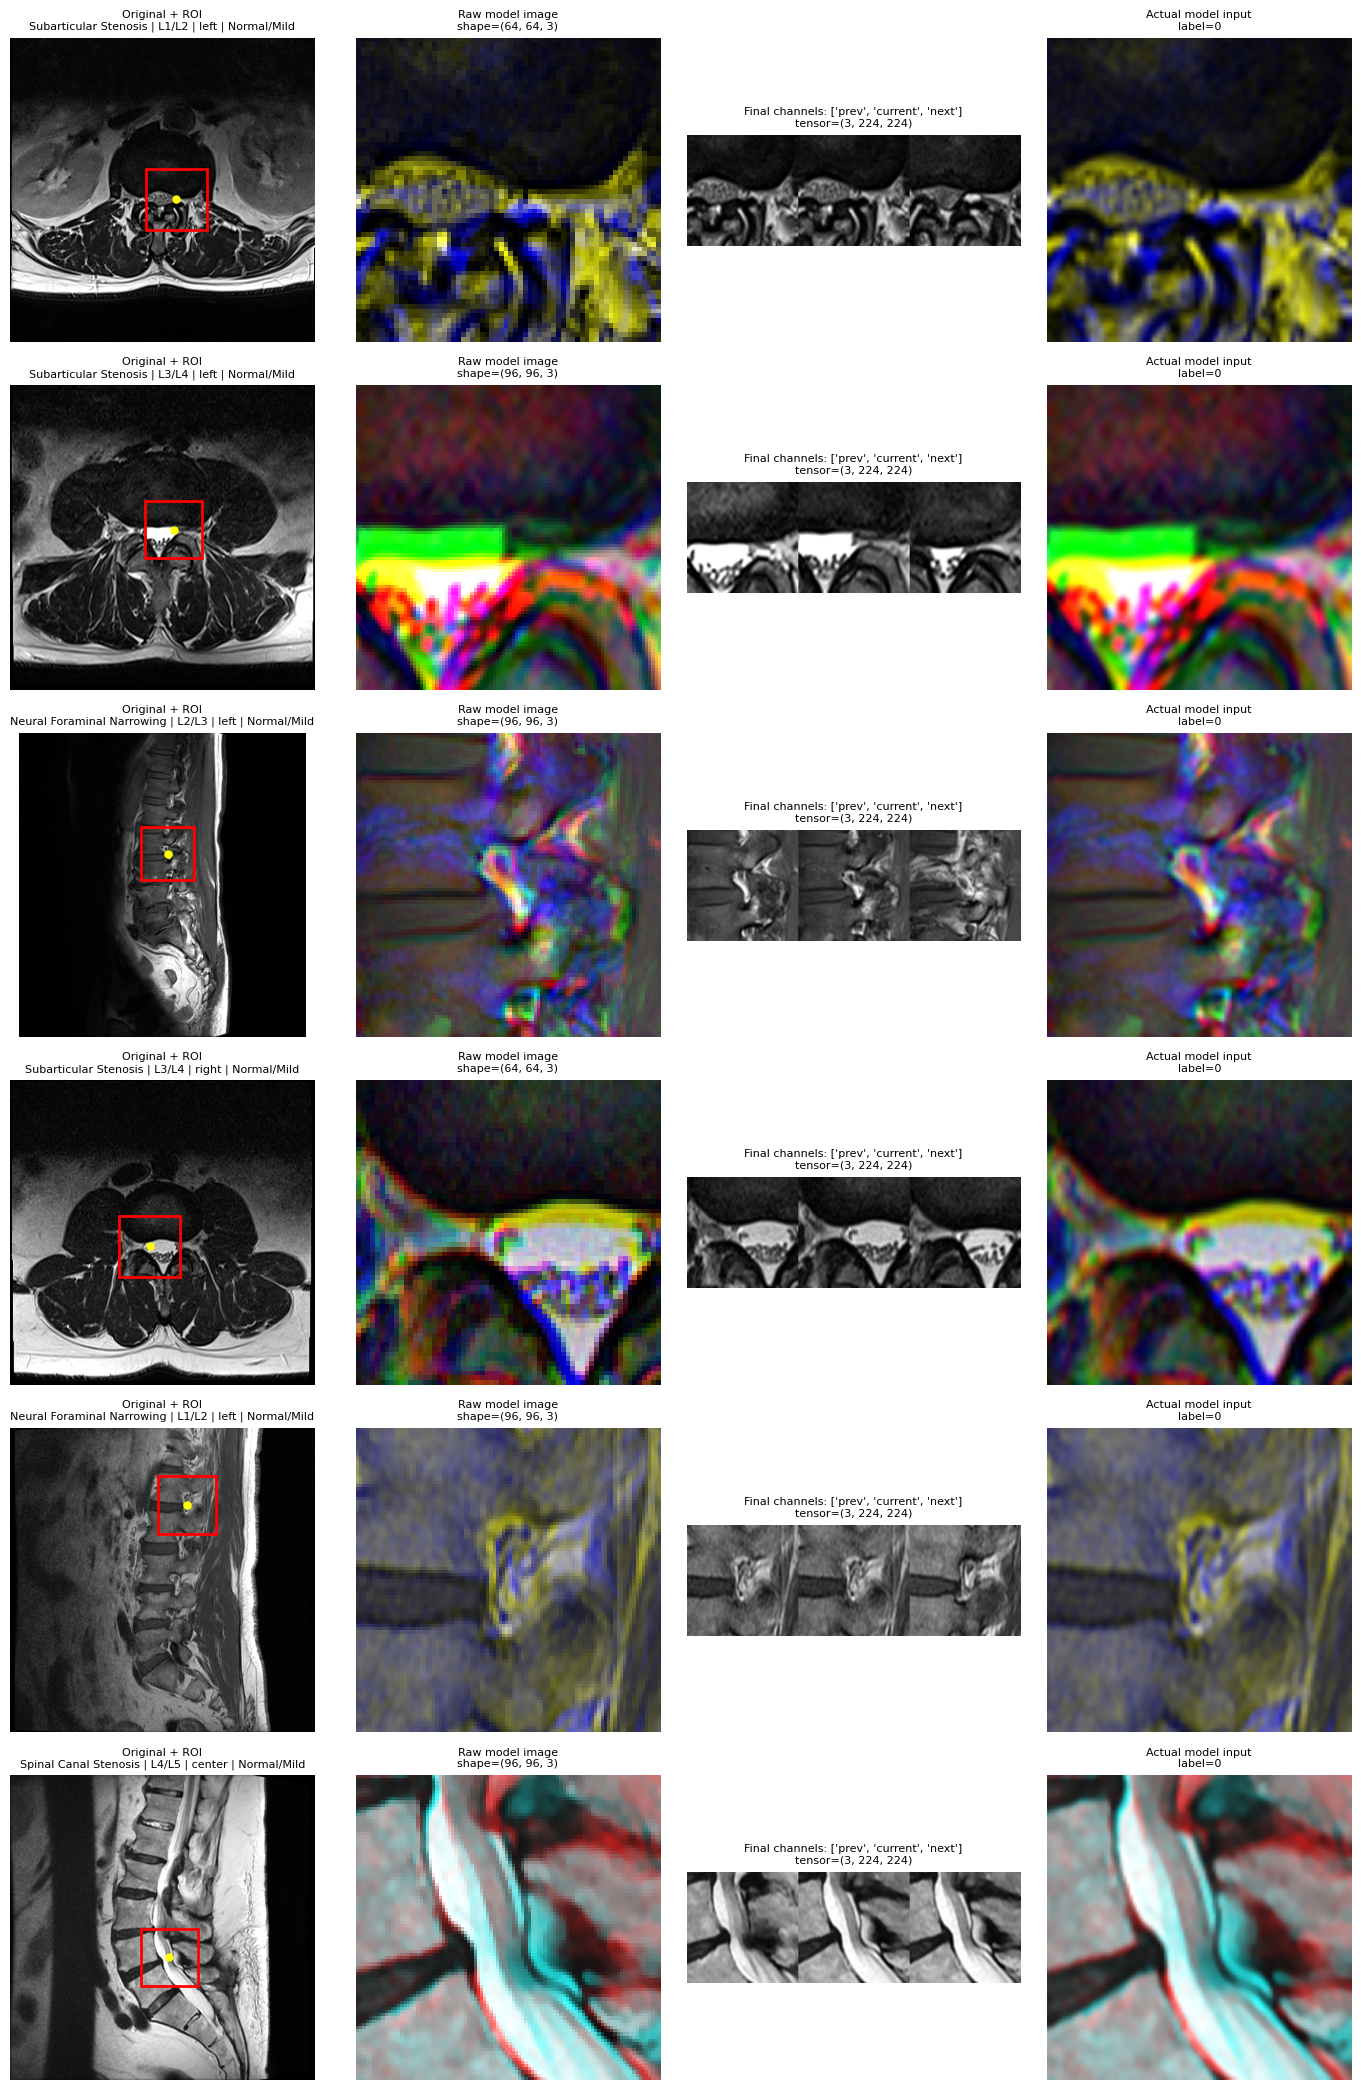

In [17]:
# Deterministic sanity dataset: same preprocessing, no random augmentation.
sanity_dataset = LumbarMetadataClassificationDataset(
    norm_train_df.reset_index(drop=True),
    transform=val_transform,
    augmentation_transform=None,
    augment=False,
    use_roi_crop=ROI_CROP_ENABLED,
    use_2_5d_input=USE_2_5D_INPUT,
)

plot_dataset_input_samples(
    sanity_dataset,
    n_samples=6,
    random_state=42,
)


## 15. Train the selected classifiers


####################################################################################################
BACKBONE RUN: efficientnet_b0
Output dir: models/models_classification_EfficientNet_b_96_zoom_efficientnet_b0
####################################################################################################

Training condition: spinal_canal_stenosis | backbone: efficientnet_b0
Class counts: {'Normal/Mild': np.int64(5953), 'Moderate': np.int64(512), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.4323), 'Severe': np.float32(7.2777)}

Epoch 1/50


  0%|          | 0/212 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 1.1963 | Train acc: 0.4991 | Train bal acc: 0.4094 | Train macro F1: 0.3110
Val loss: 1.2025 | Val acc: 0.4716 | Val bal acc: 0.4907 | Val macro F1: 0.3163 | Val severe precision: 0.0768 | Val severe recall: 0.7619 | Val severe F1: 0.1395 | Checkpoint score: 0.3944 | Early-stop score: 0.3883
Saved best model: models/models_classification_EfficientNet_b_96_zoom_efficientnet_b0/spinal_canal_stenosis_best.pt

Epoch 2/50


  0%|          | 0/212 [00:00<?, ?it/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.8904 | Train acc: 0.7922 | Train bal acc: 0.7142 | Train macro F1: 0.5708
Val loss: 0.9766 | Val acc: 0.7632 | Val bal acc: 0.6744 | Val macro F1: 0.5288 | Val severe precision: 0.2744 | Val severe recall: 0.7143 | Val severe F1: 0.3965 | Checkpoint score: 0.5493 | Early-stop score: 0.5864
No early-stopping improvement for 9/10 epochs.

Epoch 48/50


  0%|          | 0/212 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.8797 | Train acc: 0.7945 | Train bal acc: 0.7112 | Train macro F1: 0.5726
Val loss: 0.9771 | Val acc: 0.7474 | Val bal acc: 0.6840 | Val macro F1: 0.5261 | Val severe precision: 0.2761 | Val severe recall: 0.7143 | Val severe F1: 0.3982 | Checkpoint score: 0.5475 | Early-stop score: 0.5862
No early-stopping improvement for 10/10 epochs.
Early stopping at epoch 48. Best checkpoint epoch was 46 with checkpoint score 0.5648.


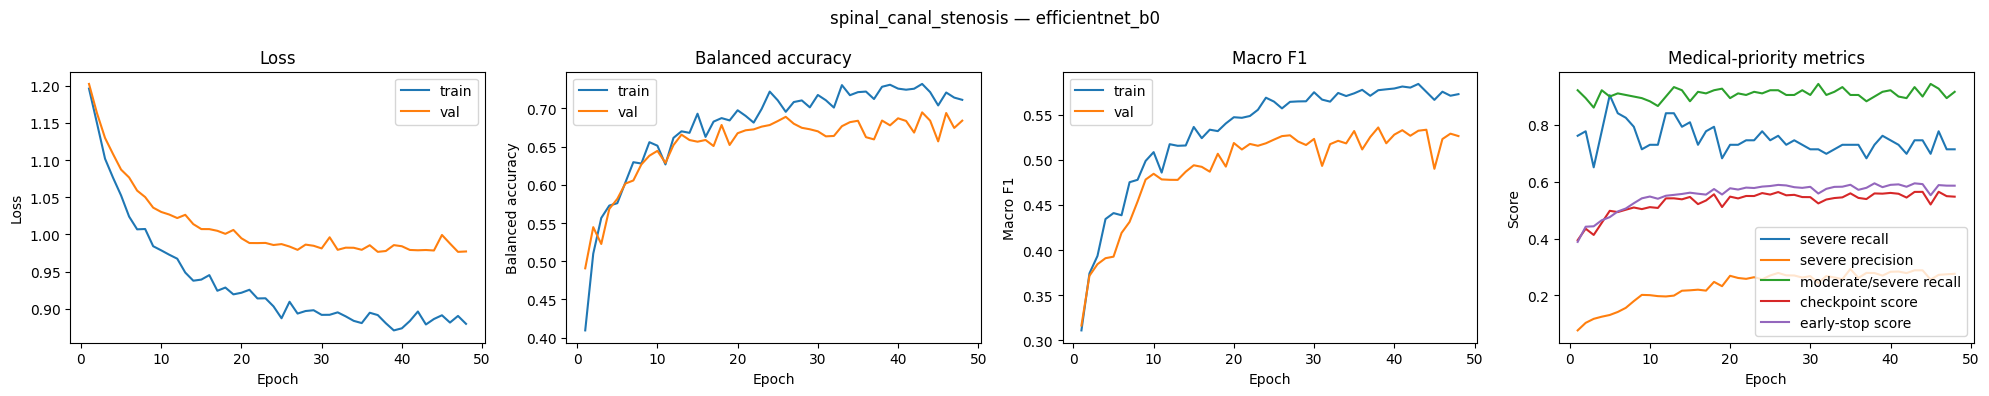


Training condition: neural_foraminal_narrowing | backbone: efficientnet_b0
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(1.8656), 'Severe': np.float32(9.7723)}

Epoch 1/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 1.1870 | Train acc: 0.5049 | Train bal acc: 0.4203 | Train macro F1: 0.3436
Val loss: 1.1604 | Val acc: 0.5621 | Val bal acc: 0.4985 | Val macro F1: 0.4046 | Val severe precision: 0.1122 | Val severe recall: 0.5182 | Val severe F1: 0.1844 | Checkpoint score: 0.3912 | Early-stop score: 0.4570
Saved best model: models/models_classification_EfficientNet_b_96_zoom_efficientnet_b0/neural_foraminal_narrowing_best.pt

Epoch 2/50


  0%|          | 0/430 [00:00<?, ?it/s]

...

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.8666 | Train acc: 0.7493 | Train bal acc: 0.7206 | Train macro F1: 0.6062
Val loss: 0.9829 | Val acc: 0.7255 | Val bal acc: 0.6473 | Val macro F1: 0.5767 | Val severe precision: 0.3304 | Val severe recall: 0.5474 | Val severe F1: 0.4121 | Checkpoint score: 0.5382 | Early-stop score: 0.6160
No early-stopping improvement for 9/10 epochs.

Epoch 40/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.8683 | Train acc: 0.7483 | Train bal acc: 0.7198 | Train macro F1: 0.6037
Val loss: 0.9701 | Val acc: 0.7191 | Val bal acc: 0.6509 | Val macro F1: 0.5679 | Val severe precision: 0.2966 | Val severe recall: 0.5693 | Val severe F1: 0.3900 | Checkpoint score: 0.5368 | Early-stop score: 0.6148
No early-stopping improvement for 10/10 epochs.
Early stopping at epoch 40. Best checkpoint epoch was 30 with checkpoint score 0.5547.


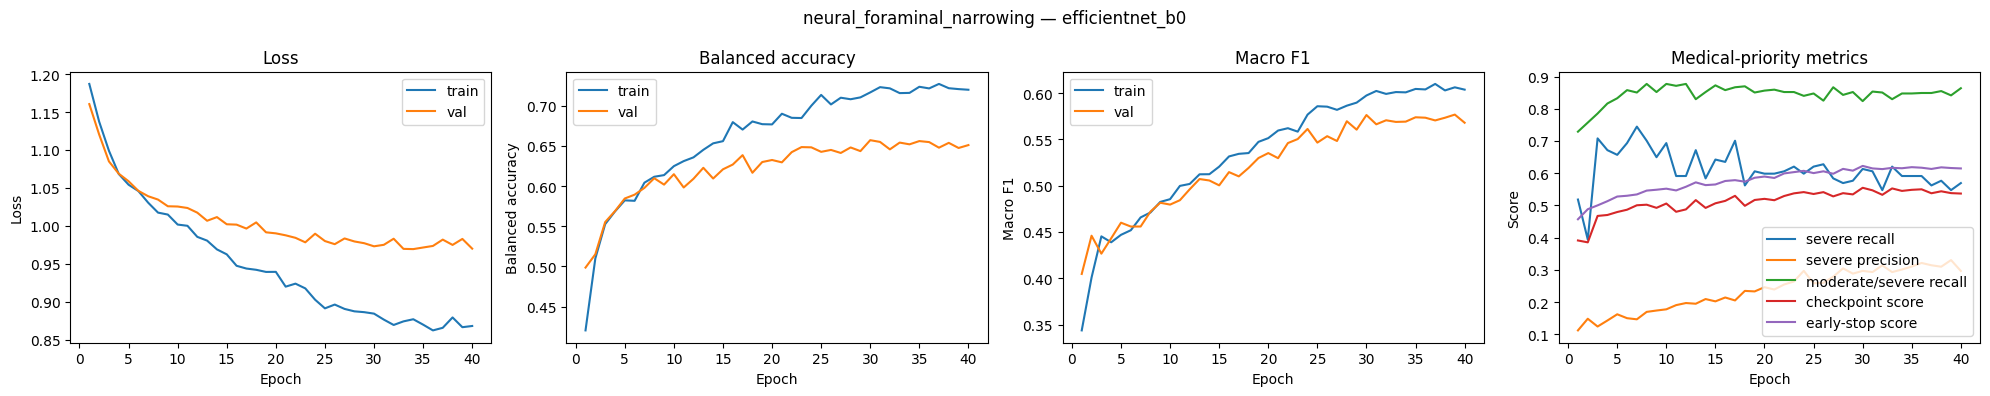


Training condition: subarticular_stenosis | backbone: efficientnet_b0
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.7577), 'Severe': np.float32(3.8175)}

Epoch 1/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 1.0851 | Train acc: 0.4850 | Train bal acc: 0.4481 | Train macro F1: 0.3776
Val loss: 1.0558 | Val acc: 0.5752 | Val bal acc: 0.4990 | Val macro F1: 0.3952 | Val severe precision: 0.1998 | Val severe recall: 0.7263 | Val severe F1: 0.3134 | Checkpoint score: 0.4960 | Early-stop score: 0.4689
Saved best model: models/models_classification_EfficientNet_b_96_zoom_efficientnet_b0/subarticular_stenosis_best.pt

Epoch 2/50


  0%|          | 0/420 [00:00<?, ?it/s]

...

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.7195 | Train acc: 0.7513 | Train bal acc: 0.7325 | Train macro F1: 0.6735
Val loss: 0.8432 | Val acc: 0.7145 | Val bal acc: 0.6572 | Val macro F1: 0.6115 | Val severe precision: 0.4719 | Val severe recall: 0.7044 | Val severe F1: 0.5652 | Checkpoint score: 0.6415 | Early-stop score: 0.6459
No early-stopping improvement for 1/10 epochs.

Epoch 50/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.7178 | Train acc: 0.7597 | Train bal acc: 0.7356 | Train macro F1: 0.6807
Val loss: 0.8547 | Val acc: 0.7326 | Val bal acc: 0.6550 | Val macro F1: 0.6238 | Val severe precision: 0.5042 | Val severe recall: 0.6642 | Val severe F1: 0.5732 | Checkpoint score: 0.6369 | Early-stop score: 0.6514
No early-stopping improvement for 2/10 epochs.


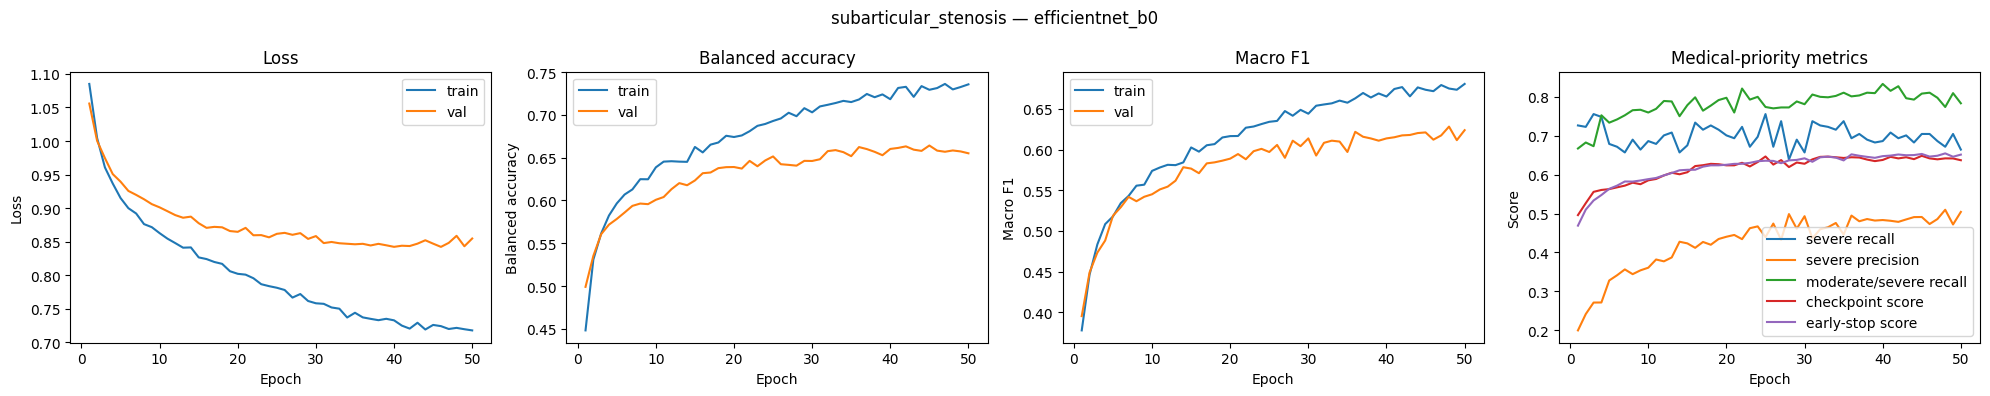

In [18]:
# ============================================================
# TRAIN SELECTED BACKBONES
# ============================================================

import gc

trained_models = {}
histories = {}

for backbone_name in SELECTED_BACKBONES:
    run_dir = set_backbone_run(backbone_name)

    print("\n" + "#" * 100)
    print(f"BACKBONE RUN: {backbone_name}")
    print(f"Output dir: {run_dir}")
    print("#" * 100)

    trained_models[backbone_name] = {}
    histories[backbone_name] = {}

    for model_name in MODELS_TO_TRAIN:
        print("\n" + "=" * 80)
        print(f"Training condition: {model_name} | backbone: {backbone_name}")
        print("=" * 80)

        # Explicitly release old loaders/model references before creating new ones.
        try:
            del train_loader
            del val_loader
            del model
        except NameError:
            pass
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        train_part = model_dfs[model_name]["train"]
        val_part = model_dfs[model_name]["val"]

        if len(train_part) == 0 or len(val_part) == 0:
            print(f"Skipping {model_name} with {backbone_name}: empty train or validation set.")
            continue

        train_loader, val_loader = make_loaders(
            train_part,
            val_part,
            batch_size=BATCH_SIZE,
            use_weighted_sampler=USE_WEIGHTED_SAMPLER,
        )

        model = build_metadata_classifier(backbone_name=backbone_name).to(DEVICE)

        criterion = make_training_criterion(train_part)
        optimizer = make_training_optimizer(model)
        scheduler = make_training_scheduler(optimizer)

        model, history_df = fit_model(
            model_name=model_name,
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=DEVICE,
            epochs=EPOCHS,
            min_epochs=MIN_EPOCHS,
            patience=PATIENCE,
            min_delta=MIN_DELTA,
            checkpoint_score_fn=checkpoint_score_fn,
            early_stop_score_fn=early_stop_score_fn,
            scheduler_metric=SCHEDULER_MONITOR,
        )

        trained_models[backbone_name][model_name] = model
        histories[backbone_name][model_name] = history_df

        plot_history(history_df, title=f"{model_name} — {backbone_name}")


## 16. Test evaluation


####################################################################################################
TESTING BACKBONE: efficientnet_b0
Output dir: models/models_classification_EfficientNet_b_96_zoom_efficientnet_b0
####################################################################################################

Testing condition: spinal_canal_stenosis | backbone: efficientnet_b0
Class counts: {'Normal/Mild': np.int64(5953), 'Moderate': np.int64(512), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.4323), 'Severe': np.float32(7.2777)}


  0%|          | 0/46 [00:00<?, ?it/s]

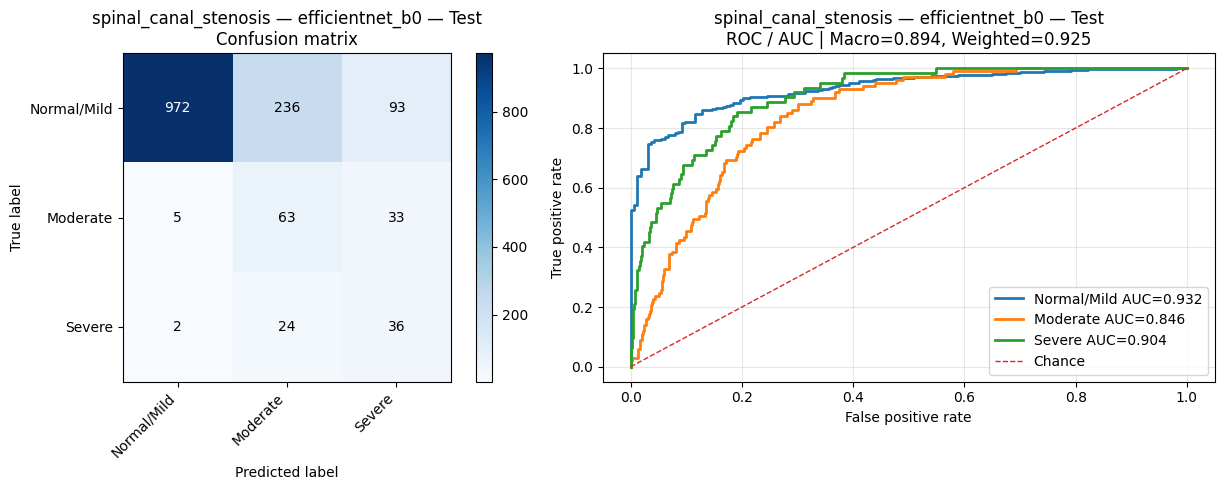

spinal_canal_stenosis — efficientnet_b0 — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.992850,0.747118,0.852632,1301.000000,0.770492,0.932001
1,Moderate,0.195046,0.623762,0.297170,101.000000,0.796448,0.845579
2,Severe,0.222222,0.580645,0.321429,62.000000,0.896175,0.904422
3,accuracy,0.731557,0.731557,0.731557,0.731557,NaN,NaN
4,macro avg,0.470040,0.650508,0.490410,1464.000000,NaN,NaN
5,weighted avg,0.905174,0.731557,0.791814,1464.000000,NaN,NaN



Testing condition: neural_foraminal_narrowing | backbone: efficientnet_b0
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(1.8656), 'Severe': np.float32(9.7723)}


  0%|          | 0/93 [00:00<?, ?it/s]

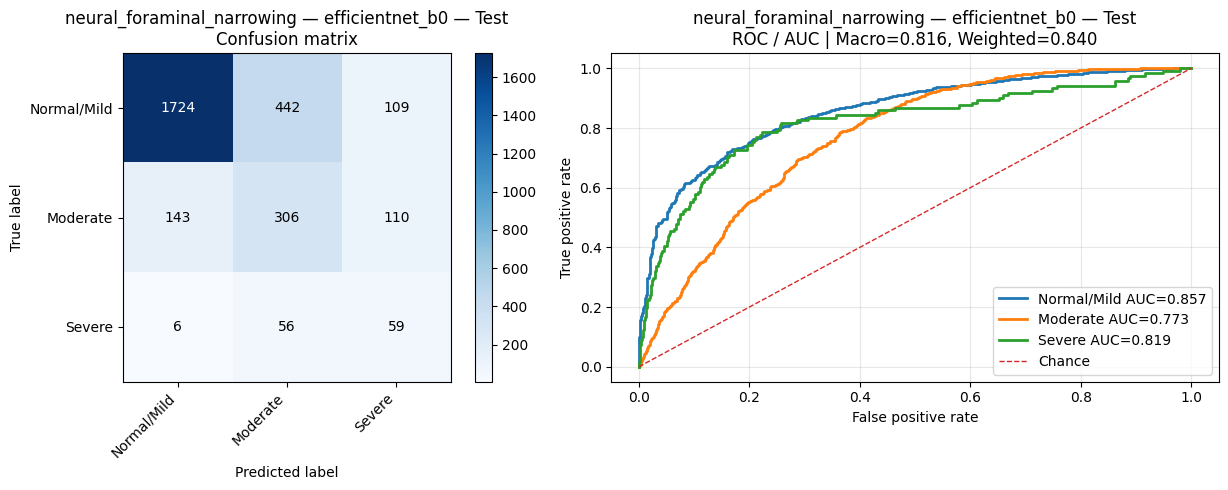

neural_foraminal_narrowing — efficientnet_b0 — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.920448,0.757802,0.831244,2275.000000,0.763113,0.857197
1,Moderate,0.380597,0.547406,0.449010,559.000000,0.745854,0.772842
2,Severe,0.212230,0.487603,0.295739,121.000000,0.904907,0.818541
3,accuracy,0.706937,0.706937,0.706937,0.706937,NaN,NaN
4,macro avg,0.504425,0.597604,0.525331,2955.000000,NaN,NaN
5,weighted avg,0.789324,0.706937,0.737009,2955.000000,NaN,NaN



Testing condition: subarticular_stenosis | backbone: efficientnet_b0
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.7577), 'Severe': np.float32(3.8175)}


  0%|          | 0/91 [00:00<?, ?it/s]

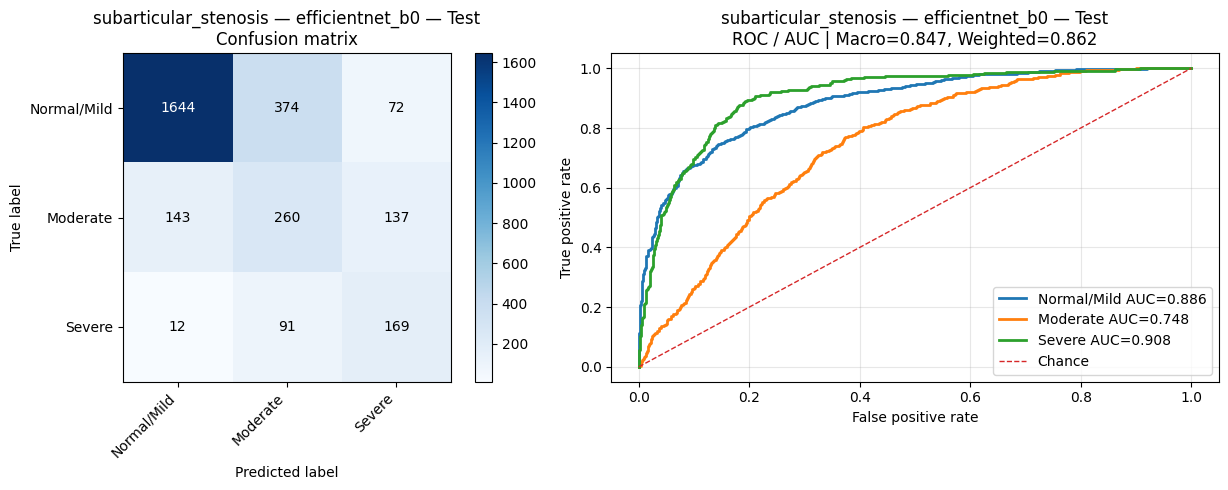

subarticular_stenosis — efficientnet_b0 — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.913841,0.786603,0.845462,2090.000000,0.792901,0.886070
1,Moderate,0.358621,0.481481,0.411067,540.000000,0.743280,0.747722
2,Severe,0.447090,0.621324,0.520000,272.000000,0.892488,0.907877
3,accuracy,0.714335,0.714335,0.714335,0.714335,NaN,NaN
4,macro avg,0.573184,0.629803,0.592176,2902.000000,NaN,NaN
5,weighted avg,0.766779,0.714335,0.734125,2902.000000,NaN,NaN


,model,input,backbone,pretrained,run_dir,loss_name,optimizer_name,scheduler_name,scheduler_monitor,learning_rate,...,test_pathological_recall,test_pathological_f1,n_test_rows,n_test_studies,test_acc_normal_mild_ovr,test_auc_normal_mild_ovr,test_acc_moderate_ovr,test_auc_moderate_ovr,test_acc_severe_ovr,test_auc_severe_ovr
0,spinal_canal_stenosis,roi_crop_2p5d_plus_metadata,efficientnet_b0,True,models/models_classification_EfficientNet_b_96...,weighted_cross_entropy,adamw,reduce_lr_on_plateau,macro_f1,0.00001,...,0.957055,0.481481,1464,297,0.770492,0.932001,0.796448,0.845579,0.896175,0.904422
1,neural_foraminal_narrowing,roi_crop_2p5d_plus_metadata,efficientnet_b0,True,models/models_classification_EfficientNet_b_96...,weighted_cross_entropy,adamw,reduce_lr_on_plateau,macro_f1,0.00001,...,0.780882,0.602724,2955,296,0.763113,0.857197,0.745854,0.772842,0.904907,0.818541
2,subarticular_stenosis,roi_crop_2p5d_plus_metadata,efficientnet_b0,True,models/models_classification_EfficientNet_b_96...,weighted_cross_entropy,adamw,reduce_lr_on_plateau,macro_f1,0.00001,...,0.809113,0.686162,2902,297,0.792901,0.886070,0.743280,0.747722,0.892488,0.907877


Saved combined results: models/models_classification_EfficientNet_b_96_zoom_selected_backbones/test_results_selected_backbones_pretrained.csv


In [19]:
# ============================================================
# TEST EVALUATION FOR SELECTED BACKBONES
# ============================================================

test_results = []

for backbone_name in SELECTED_BACKBONES:
    run_dir = set_backbone_run(backbone_name)

    print("\n" + "#" * 100)
    print(f"TESTING BACKBONE: {backbone_name}")
    print(f"Output dir: {run_dir}")
    print("#" * 100)

    for model_name in MODELS_TO_TRAIN:
        print("\n" + "=" * 80)
        print(f"Testing condition: {model_name} | backbone: {backbone_name}")
        print("=" * 80)

        test_part = model_dfs[model_name]["test"]

        if len(test_part) == 0:
            print(f"Skipping {model_name} with {backbone_name}: empty test set.")
            continue

        model_path = OUTPUT_DIR / f"{model_name}_best.pt"
        if not model_path.exists():
            print(f"Skipping {model_name} with {backbone_name}: missing checkpoint {model_path}")
            continue

        model = load_best_model(model_name, backbone_name=backbone_name)
        test_loader = make_test_loader(test_part, batch_size=BATCH_SIZE)

        # Use train split for loss weights; metrics are the primary comparison.
        criterion = make_training_criterion(model_dfs[model_name]["train"])

        metrics = evaluate_one_epoch(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        # ------------------------------------------------------------
        # Combined plot: confusion matrix + ROC/AUC
        # ------------------------------------------------------------
        combined_plot_path = OUTPUT_DIR / f"{model_name}_{backbone_name}_test_confusion_and_roc.png"

        macro_auc, weighted_auc = plot_confusion_and_roc_side_by_side(
            metrics["y_true"],
            metrics["y_pred"],
            metrics["y_prob"],
            class_names=TARGET_NAMES,
            title_prefix=f"{model_name} — {backbone_name} — Test",
            save_path=combined_plot_path,
        )

        # ------------------------------------------------------------
        # One report table: precision, recall, f1, support, acc_ovr, auc_ovr
        # ------------------------------------------------------------
        report_table, macro_auc, weighted_auc = make_report_table(
            metrics["y_true"],
            metrics["y_pred"],
            metrics["y_prob"],
            class_names=TARGET_NAMES,
        )

        print(f"{model_name} — {backbone_name} — classification report")
        display(report_table)

        row = {
            "model": model_name,
            "input": "roi_crop_2p5d_plus_metadata" if USE_2_5D_INPUT else "roi_crop_repeated_gray_plus_metadata",
            "backbone": backbone_name,
            "pretrained": PRETRAINED,
            "run_dir": str(OUTPUT_DIR),
            "loss_name": LOSS_NAME,
            "optimizer_name": OPTIMIZER_NAME,
            "scheduler_name": SCHEDULER_NAME,
            "scheduler_monitor": SCHEDULER_MONITOR,
            "learning_rate": LR,
            "weight_decay": WEIGHT_DECAY,
            "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
            "moderate_weight_multiplier": MODERATE_WEIGHT_MULTIPLIER,
            "severe_weight_multiplier": SEVERE_WEIGHT_MULTIPLIER,
            "label_smoothing": LABEL_SMOOTHING,
            "hidden_dim": HIDDEN_DIM,
            "dropout": DROPOUT,
            "backbone_lr_multiplier": BACKBONE_LR_MULTIPLIER,
            "epochs": EPOCHS,
            "min_epochs": MIN_EPOCHS,
            "patience": PATIENCE,
            "min_delta": MIN_DELTA,
            "checkpoint_score_weights": str(CHECKPOINT_SCORE_WEIGHTS),
            "early_stop_score_weights": str(EARLY_STOP_SCORE_WEIGHTS),
            "test_loss": metrics["loss"],
            "test_log_loss": metrics["log_loss"],
            "test_accuracy": metrics["accuracy"],
            "test_balanced_accuracy": metrics["balanced_accuracy"],
            "test_macro_f1": metrics["macro_f1"],
            "test_macro_auc_ovr": macro_auc,
            "test_weighted_auc_ovr": weighted_auc,
            "test_severe_precision": metrics["severe_precision"],
            "test_severe_recall": metrics["severe_recall"],
            "test_severe_f1": metrics["severe_f1"],
            "test_pathological_precision": metrics["pathological_precision"],
            "test_pathological_recall": metrics["pathological_recall"],
            "test_pathological_f1": metrics["pathological_f1"],
            "n_test_rows": len(test_part),
            "n_test_studies": test_part["study_id"].nunique(),
        }

        # Add class-wise AUC and one-vs-rest accuracy into the main results table.
        for _, report_row in report_table.iterrows():
            class_name = report_row["class"]

            if class_name not in TARGET_NAMES:
                continue

            safe_class_name = (
                class_name
                .lower()
                .replace("/", "_")
                .replace(" ", "_")
                .replace("-", "_")
            )

            row[f"test_acc_{safe_class_name}_ovr"] = report_row["acc_ovr"]
            row[f"test_auc_{safe_class_name}_ovr"] = report_row["auc_ovr"]

        test_results.append(row)

results_table = pd.DataFrame(test_results)
display(results_table)

suffix = "pretrained" if PRETRAINED else "scratch"
results_path = OUTPUT_ROOT_DIR / f"test_results_selected_backbones_{suffix}.csv"
results_table.to_csv(results_path, index=False)

print("Saved combined results:", results_path)
